# E03 — distributed nonlinear inverse problem


All seven methods use the same outer optimization protocol. For method \(k\), the data objective and its data gradient are normalized by the fixed initial value
\[
\widehat J_k(m)=\frac{J_k(m)}{J_k(m_0)},\qquad
\nabla_d \widehat J_k=\frac{\nabla_d J_k}{J_k(m_0)}.
\]
The notebook first runs gradient gates, then all formal inversions. **Every outer Adam iteration is printed** with relative model error, correlation, objective, and gradient norm.

In [11]:
from IPython.display import display, Image
import os
import sys
import subprocess
from pathlib import Path

# ============================================================
# Locate the qvvw2 repository
# ============================================================

ROOT = Path.cwd().resolve()

for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError(
        "Could not locate the qvvw2 repository root."
    )

os.chdir(ROOT)

# ============================================================
# Make sure the current repository is installed
# ============================================================

def current_qvvw2_path():
    try:
        import qvvw2
        return Path(qvvw2.__file__).resolve()
    except ImportError:
        return None


installed_path = current_qvvw2_path()

need_install = (
    installed_path is None
    or ROOT not in installed_path.parents
)

if need_install:
    print("Preparing local qvvw2 package...")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-e",
            str(ROOT),
            "--no-deps",
            "--no-build-isolation",
            "--quiet",
        ],
        check=True,
    )

# Make the current checkout take priority.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import qvvw2

# ============================================================
# Environment used by experiment subprocesses
# ============================================================

existing_pythonpath = os.environ.get(
    "PYTHONPATH",
    ""
)

pythonpath_parts = [
    str(ROOT)
]

if existing_pythonpath:
    pythonpath_parts.append(
        existing_pythonpath
    )

os.environ["PYTHONPATH"] = os.pathsep.join(
    pythonpath_parts
)

print("Repository :", ROOT)
print("Python     :", sys.executable)
print("qvvw2      :", Path(qvvw2.__file__).resolve())


# ============================================================
# Helper for running experiment scripts
# ============================================================

def run_py(relative_path, *args):
    script = ROOT / relative_path

    if not script.exists():
        raise FileNotFoundError(
            f"Experiment script not found: {script}"
        )

    cmd = [
        sys.executable,
        "-u",
        str(script),
        *map(str, args),
    ]

    env = dict(os.environ)

    print(
        "\n" + "=" * 88,
        flush=True,
    )
    print(
        "RUN:",
        " ".join(cmd),
        flush=True,
    )
    print(
        "=" * 88,
        flush=True,
    )

    subprocess.run(
        cmd,
        cwd=ROOT,
        env=env,
        check=True,
    )


def reset_experiment(exp_id):
    """
    Remove only previously generated results and figures for the
    selected experiment before a fresh rerun.

    Source code, notebooks, inputs, and all other experiments are
    untouched.
    """
    import shutil

    exp = ROOT / "experiments" / exp_id

    for name in ("results", "figures"):
        path = exp / name

        if path.exists():
            shutil.rmtree(path)

    print(
        f"[{exp_id}] previous generated results/figures cleared.",
        flush=True,
    )



Repository : /root/autodl-tmp/qvvw2
Python     : /root/miniconda3/envs/qvvw2/bin/python
qvvw2      : /root/autodl-tmp/qvvw2/qvvw2/__init__.py


In [12]:
reset_experiment("E03")

[E03] previous generated results/figures cleared.


In [15]:
run_py("experiments/E03/code/run_hv_strict_gate.py")
run_py("experiments/E03/code/run_e03.py", "--all")
run_py("experiments/E03/code/finalize_e03.py")


RUN: /root/miniconda3/envs/qvvw2/bin/python -u /root/autodl-tmp/qvvw2/experiments/E03/code/run_hv_strict_gate.py
HV strict gate 0.003 FD 6.703706869053234e-08 analytic 6.703855849583506e-08 rel 2.222311064179182e-05
HV strict gate 0.001 FD 6.70296329228664e-08 analytic 6.703855849583506e-08 rel 0.0001331408844240742
HV strict gate 0.0005 FD 6.703658620489547e-08 analytic 6.703855849583506e-08 rel 2.9420246852522685e-05
HV strict gate 0.0003 FD 6.704121288378891e-08 analytic 6.703855849583506e-08 rel 3.959337606936004e-05
{
  "analytic": 6.703855849583506e-08,
  "base_value": 1.9475454524897923e-06,
  "meta": {
    "mean_inner_nit": 146.1375,
    "max_inner_nit": 384,
    "success_fraction": 1.0,
    "max_opt_grad_inf": 1.9381638556002111e-07
  },
  "params": {
    "kappa": 0.0001,
    "lam": 0.0001,
    "eps": 1e-12,
    "nt": 12,
    "maxiter": 4800,
    "gtol": 1e-10
  },
  "direction_seed": 90731,
  "rows": [
    [
      0.003,
      6.703706869053234e-08,
      2.222311064179182e-


 Fig04_distributed_reconstruction.png


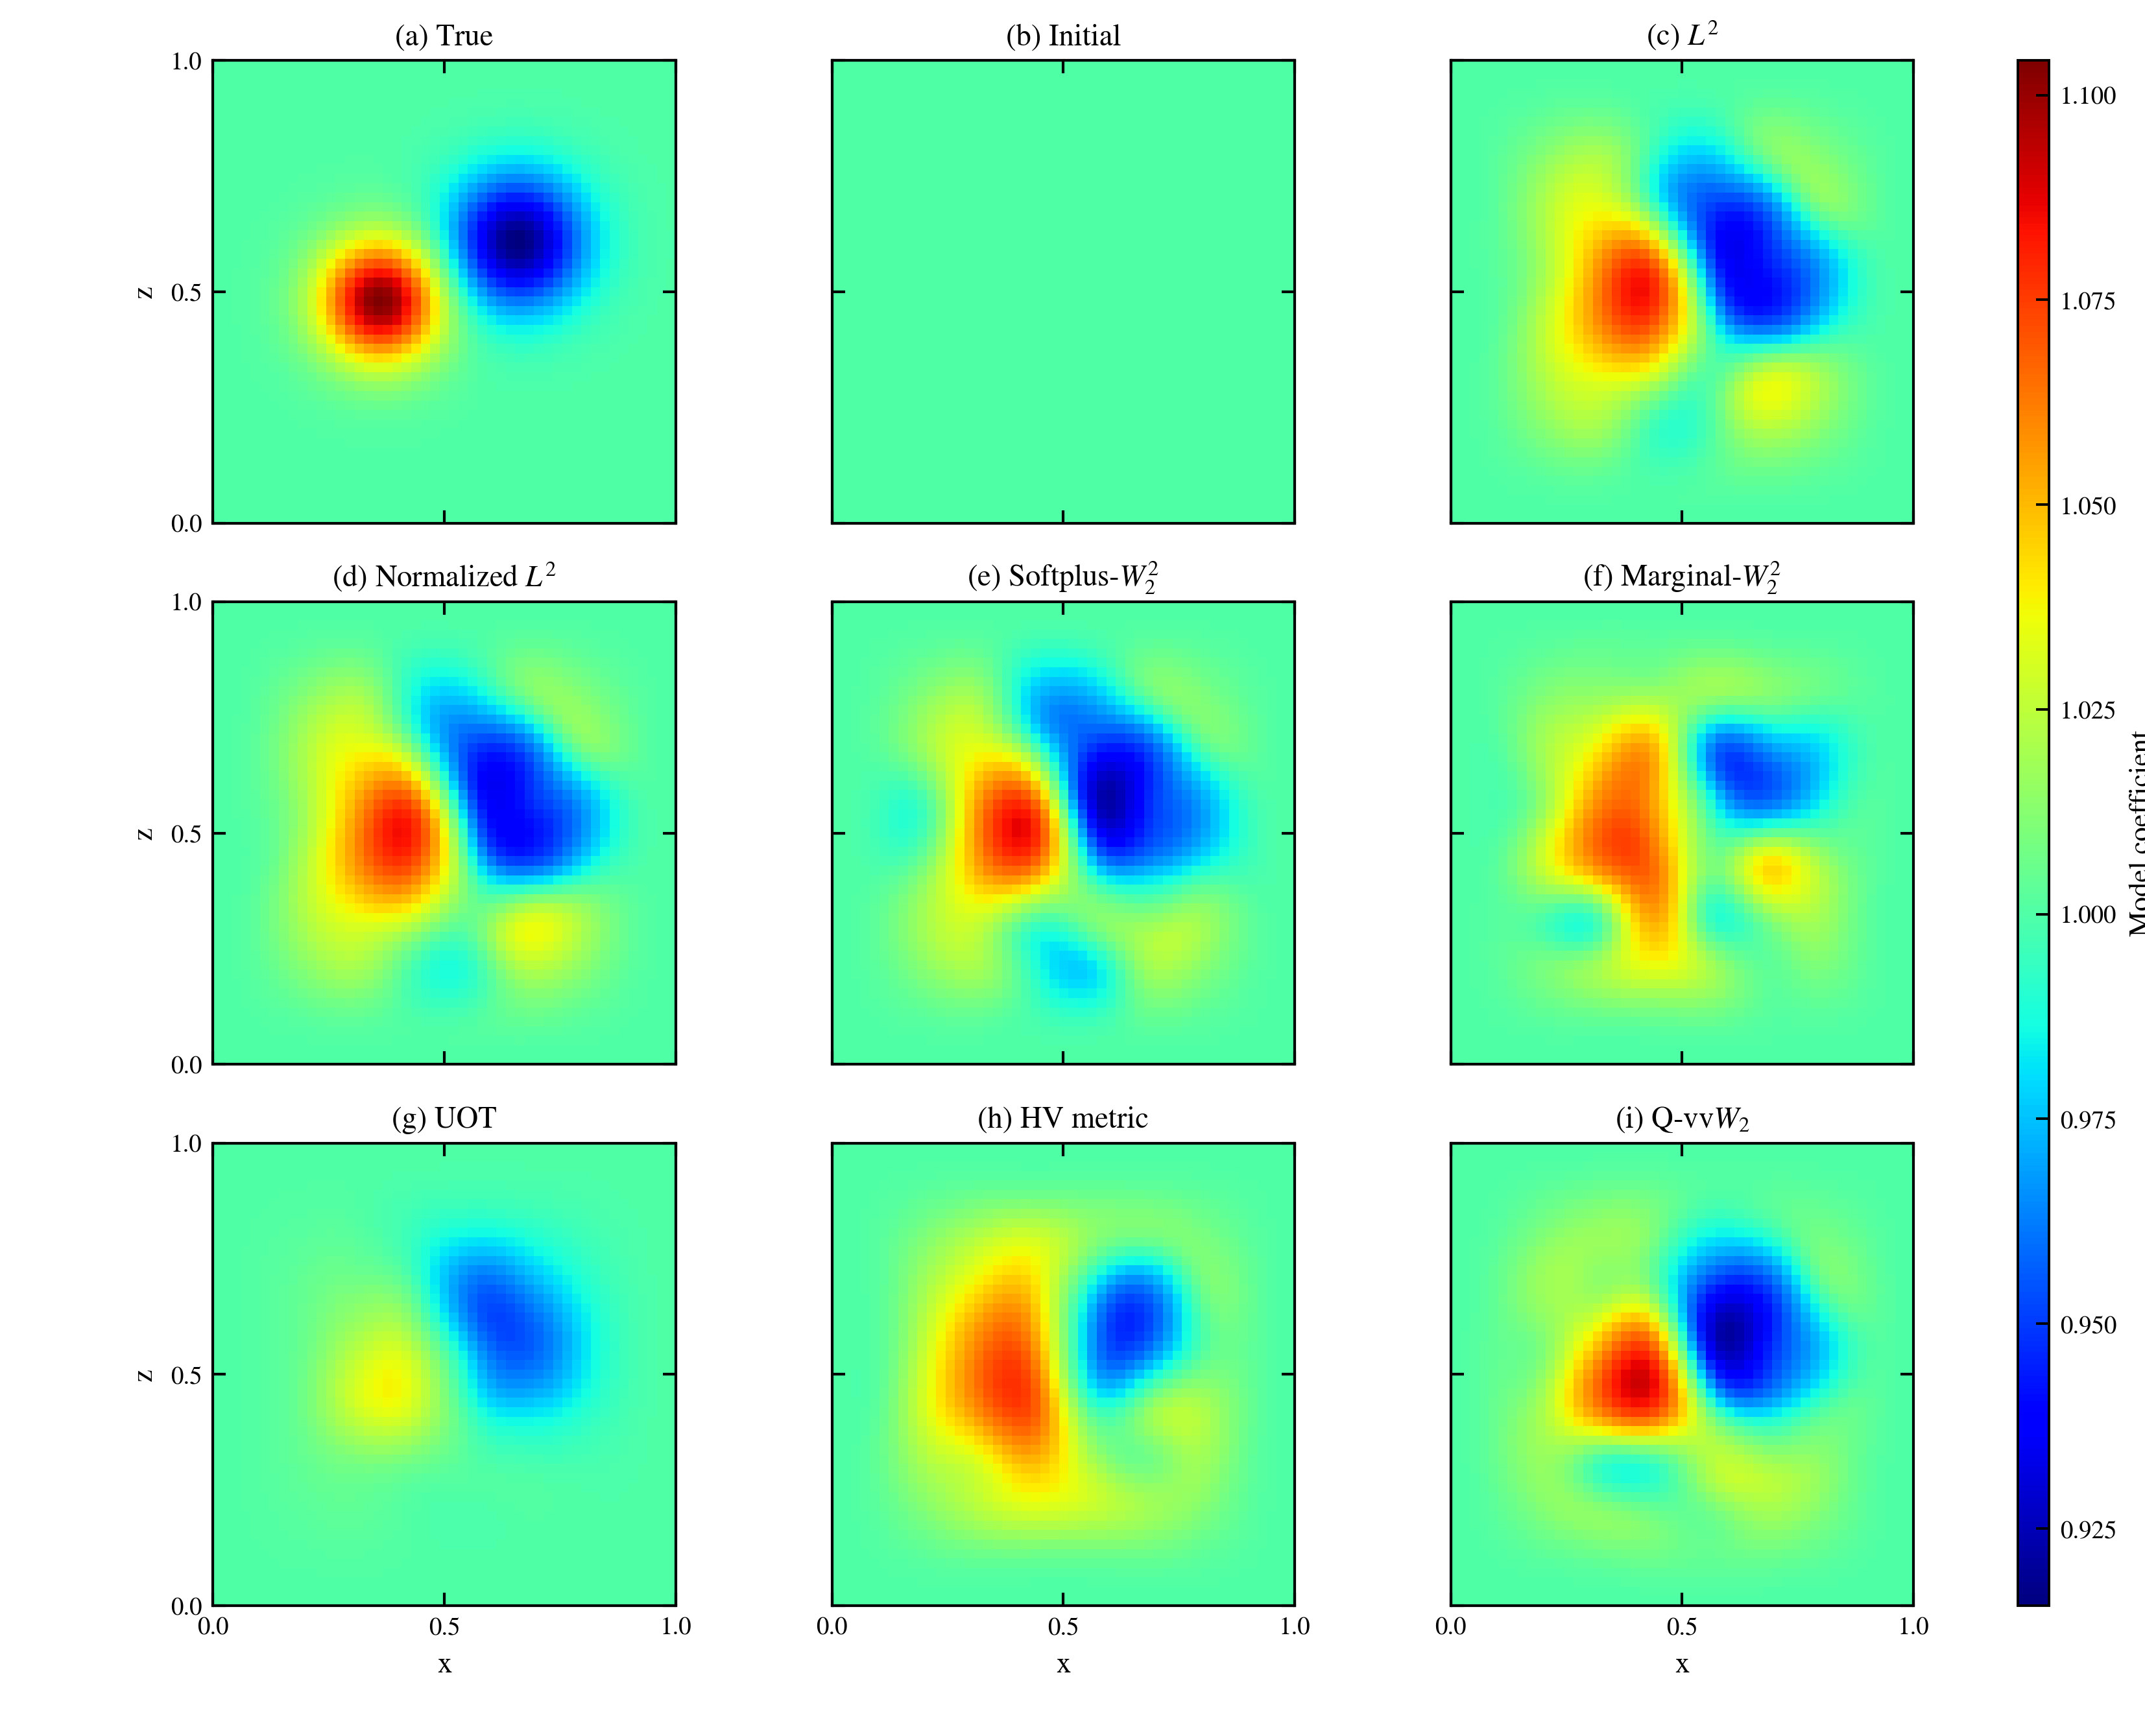


 Fig05_distributed_diagnostics.png


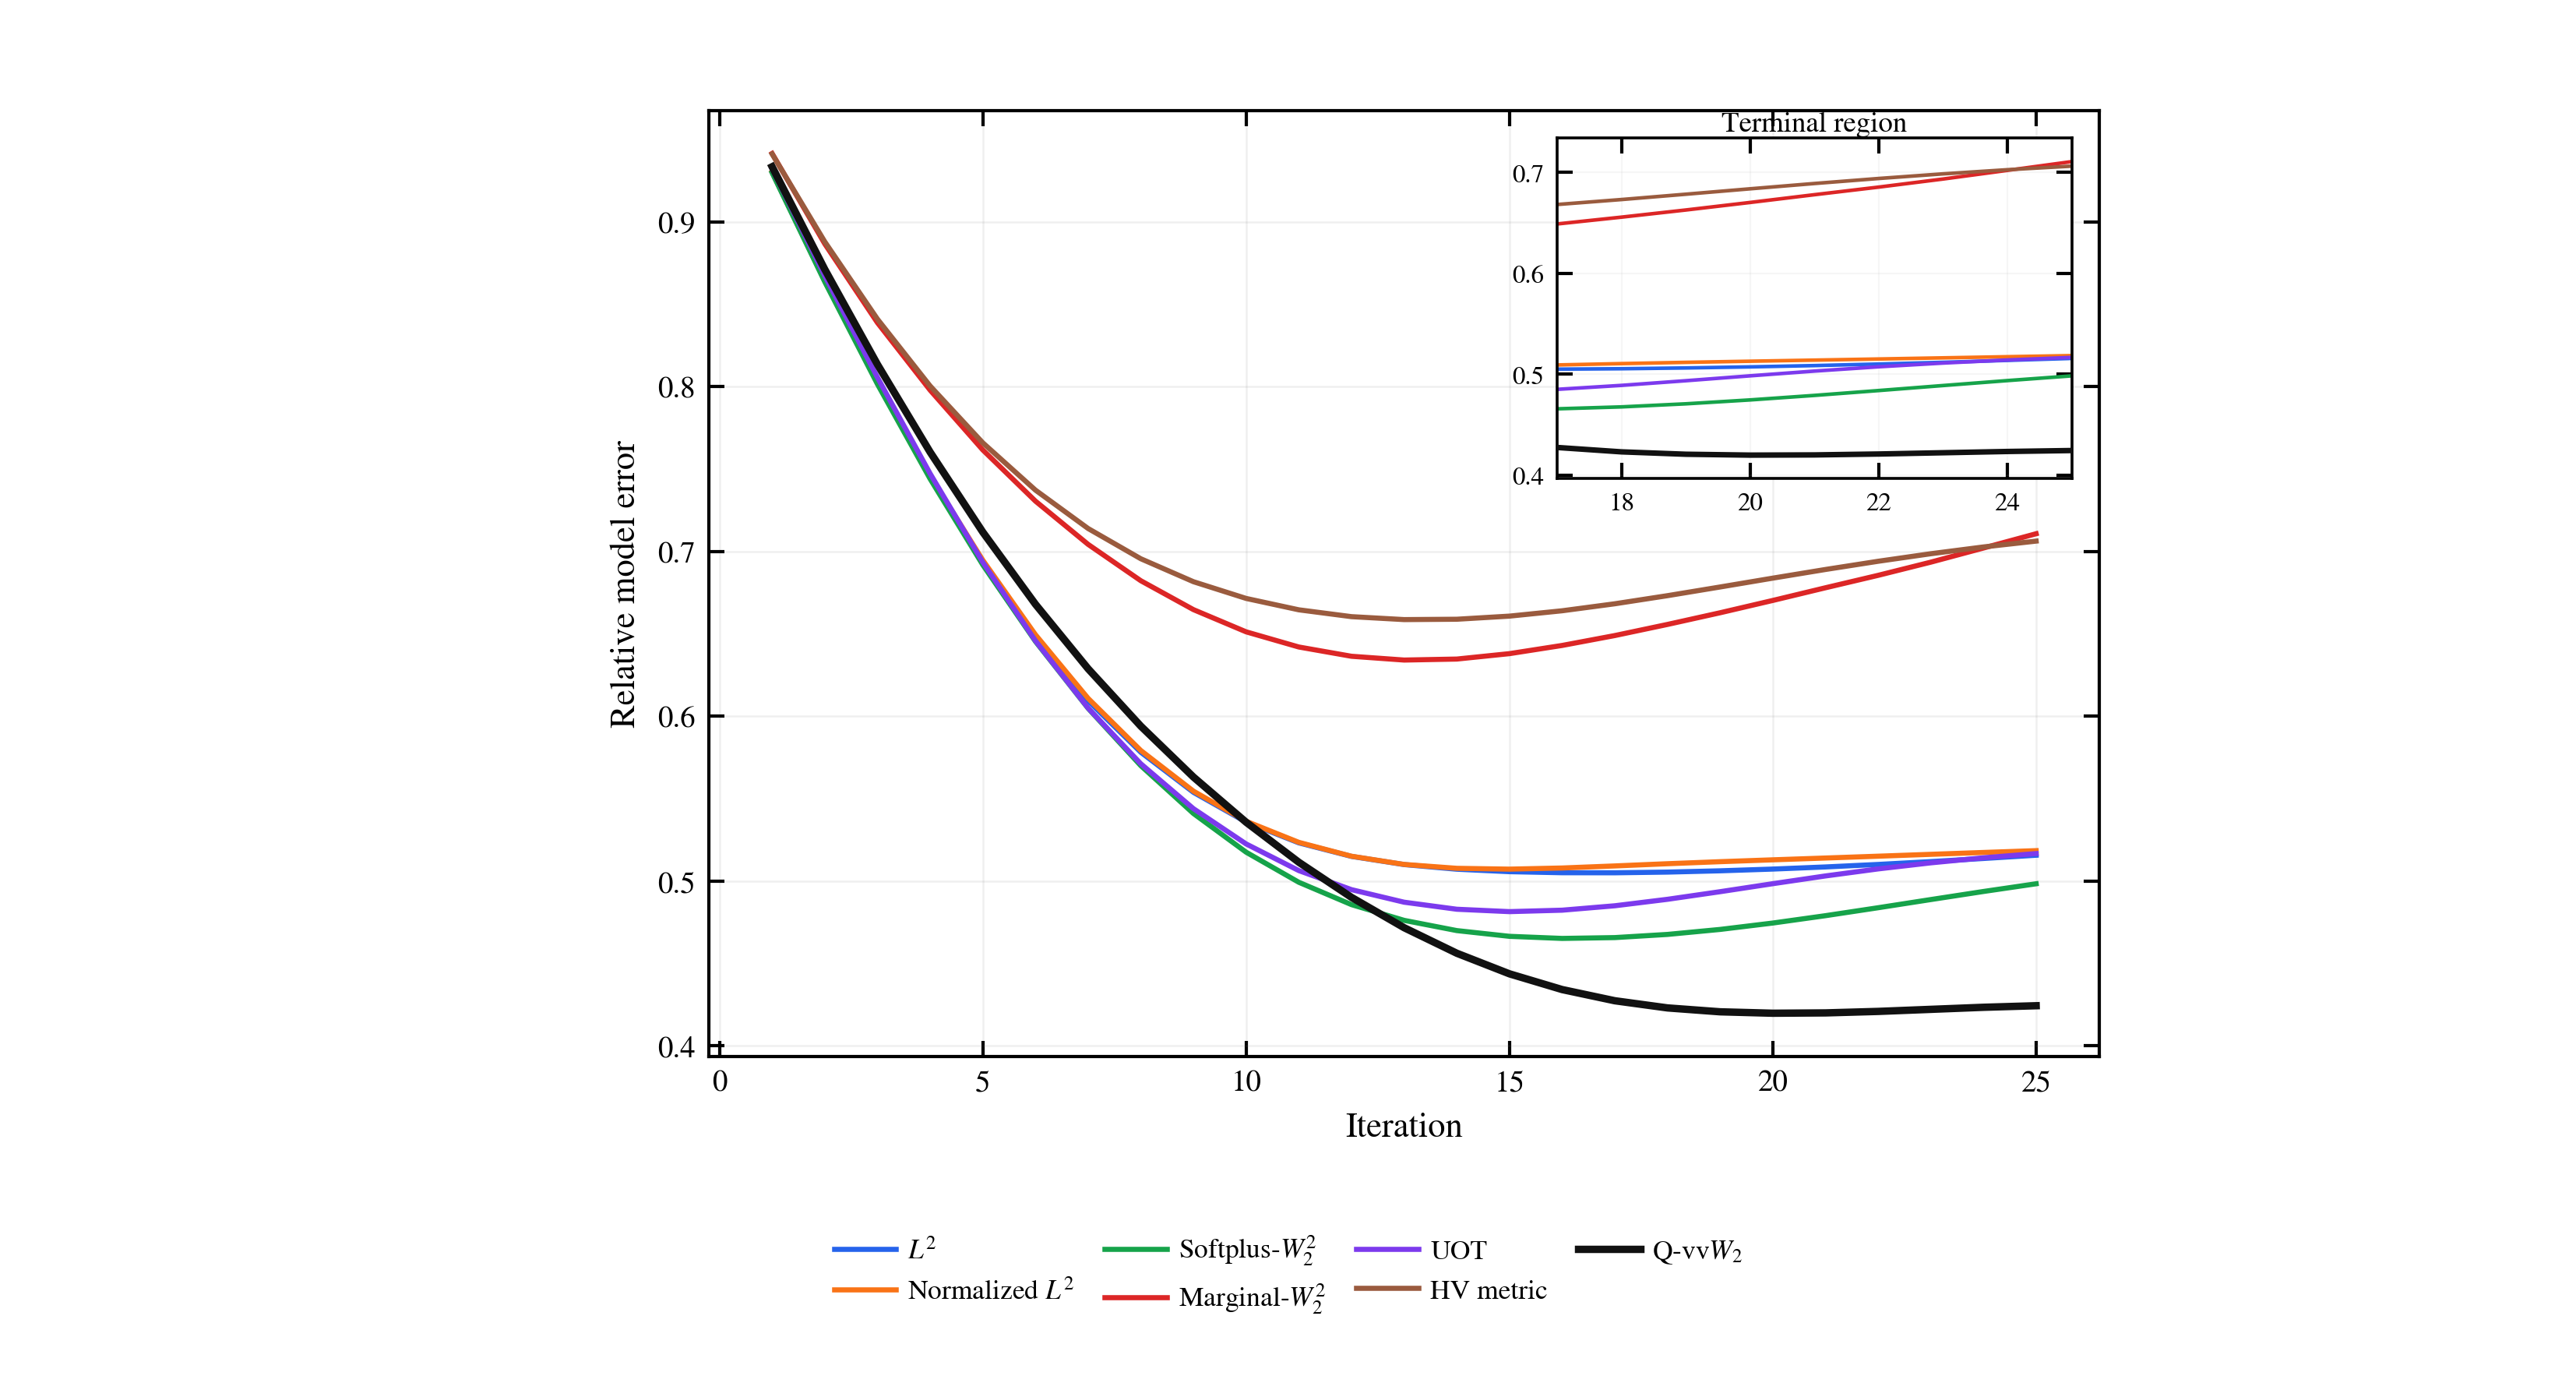


 Fig06_distributed_profiles_scaling_robustness.png


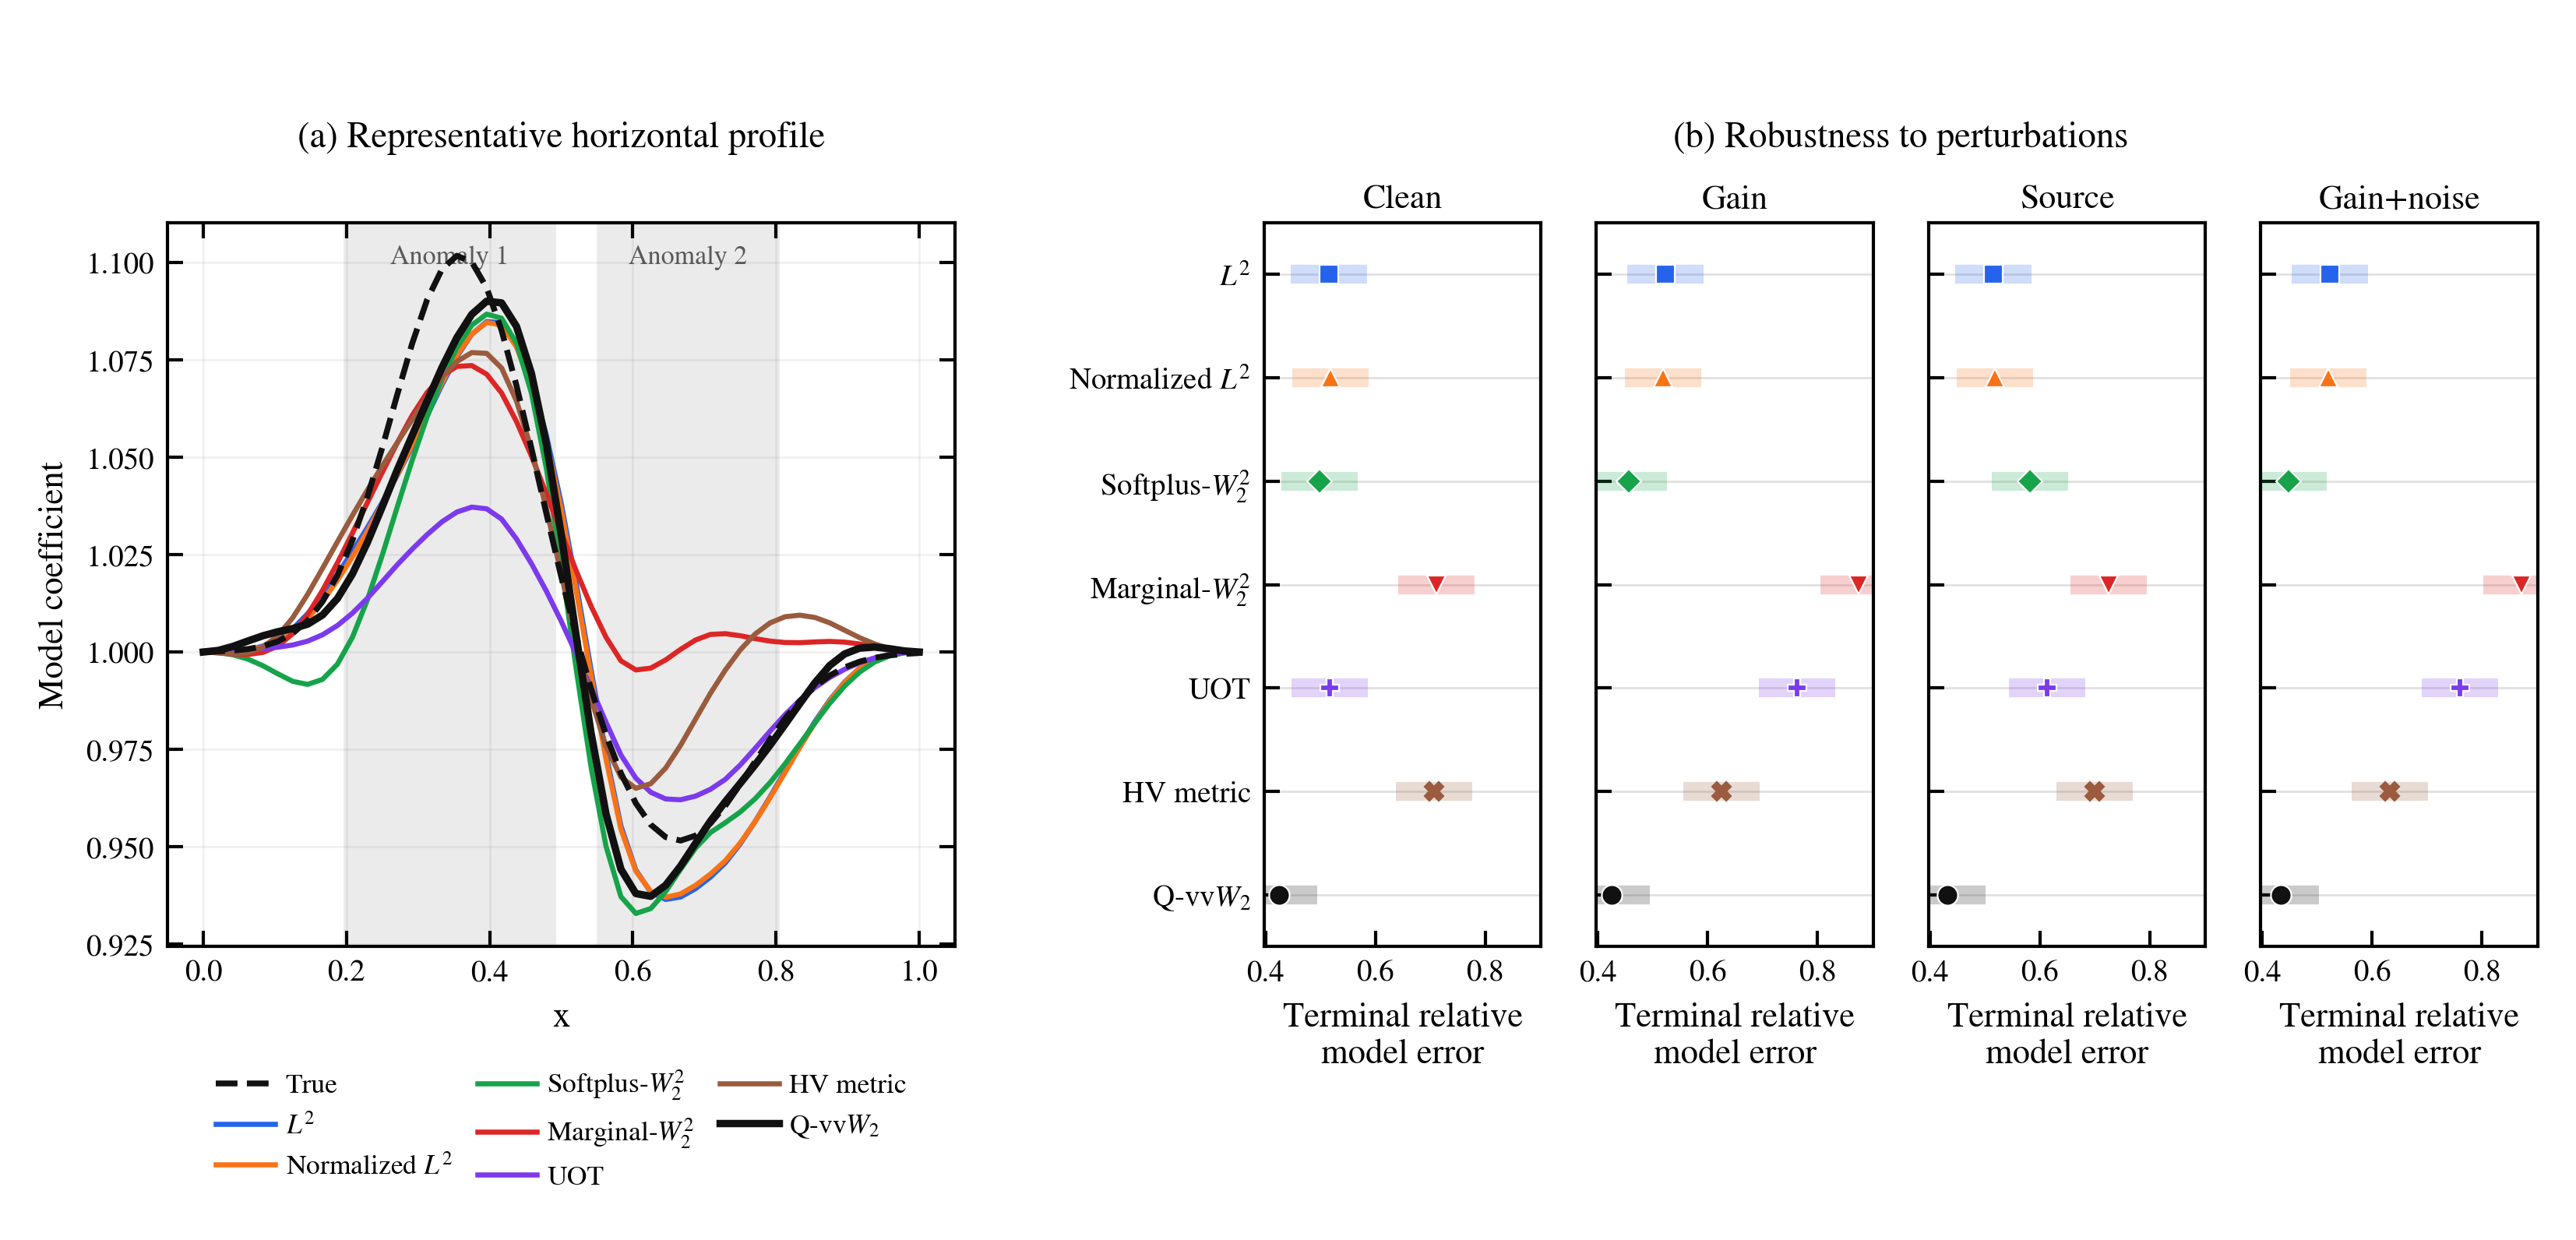

In [16]:
def show_png(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path)))

for name in ["Fig04_distributed_reconstruction.png", "Fig05_distributed_diagnostics.png", "Fig06_distributed_profiles_scaling_robustness.png"]:
    print("\n", name)
    show_png(ROOT / "experiments/E03/figures" / name)